# Lab 5 — Support Vector Machines
**Machine Learning for the Natural Sciences**

SVMs find the **widest possible margin** between classes. They can handle
non-linear boundaries using the **kernel trick** — mapping data into
higher dimensions where classes become separable.

**What you'll learn:**
- Linear SVM: maximum margin classification
- The kernel trick: RBF, polynomial kernels
- Hyperparameter tuning: C (regularization) and gamma
- Decision boundary visualization
- When SVMs shine vs. when Random Forests are better

---

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42

## 1. Prepare Data

In [2]:
df = sns.load_dataset("penguins").dropna()

feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[feature_cols]
y = df["species"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE
)

# SVMs absolutely require scaling — they're distance-based
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 2. Linear SVM
The simplest SVM: find a flat hyperplane that separates classes with
the widest margin.

In [3]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
svm_linear.fit(X_train_sc, y_train)
y_pred_lin = svm_linear.predict(X_test_sc)

print(f"Linear SVM Accuracy: {accuracy_score(y_test, y_pred_lin):.3f}")
print(f"Support vectors per class: {svm_linear.n_support_}")

Linear SVM Accuracy: 1.000
Support vectors per class: [12 11  2]


### What are Support Vectors?
Support vectors are the training points closest to the decision boundary.
They're the "hardest" examples — the ones the SVM pays most attention to.
Moving a non-support-vector doesn't change the model at all.

In [4]:
n_sv = svm_linear.n_support_.sum()
n_train = len(X_train_sc)
print(f"Support vectors: {n_sv} out of {n_train} training samples ({n_sv/n_train*100:.0f}%)")

Support vectors: 25 out of 266 training samples (9%)


## 3. The Kernel Trick
What if classes aren't linearly separable? Kernels map data into
higher dimensions where a linear boundary works.

In [5]:
# Compare kernels
kernels = {
    "Linear": SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE),
    "RBF (default)": SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE),
    "Polynomial (d=3)": SVC(kernel="poly", degree=3, C=1.0, random_state=RANDOM_STATE),
}

print(f"{'Kernel':<20} {'Accuracy':>10} {'Support Vectors':>18}")
print("-" * 50)
for name, model in kernels.items():
    model.fit(X_train_sc, y_train)
    acc = model.score(X_test_sc, y_test)
    n_sv = model.n_support_.sum()
    print(f"{name:<20} {acc:>10.3f} {n_sv:>18}")

Kernel                 Accuracy    Support Vectors
--------------------------------------------------
Linear                    1.000                 25
RBF (default)             1.000                 51
Polynomial (d=3)          0.985                 74


## 4. Decision Boundary Visualization
Using 2 features so we can see how different kernels carve up the space.

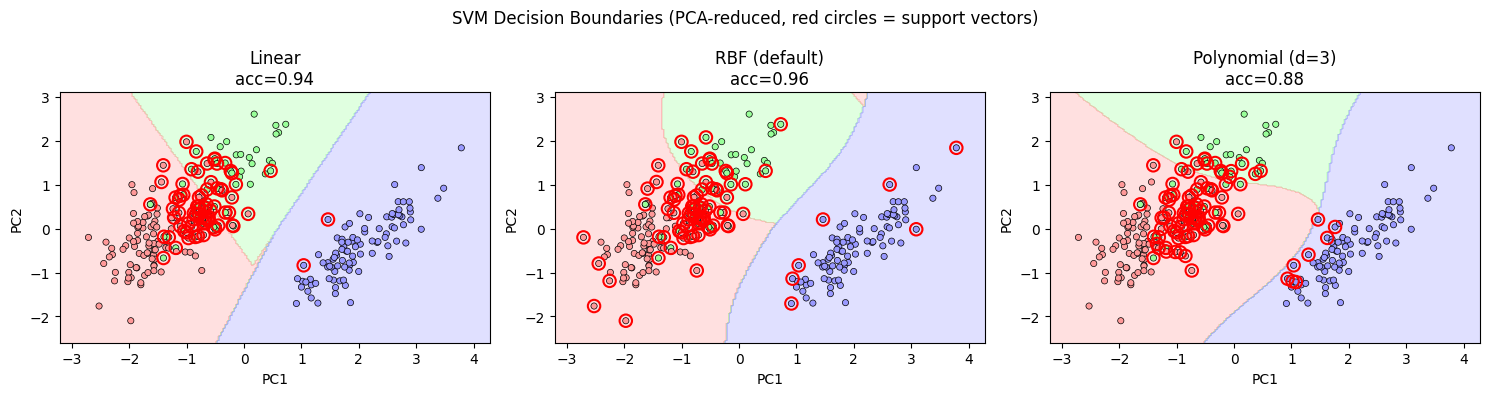

In [6]:
from matplotlib.colors import ListedColormap

# Use PCA to reduce to 2D for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(scaler.fit_transform(X))
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_encoded, test_size=0.2, random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ListedColormap(["#FF9999", "#99FF99", "#9999FF"])

for ax, (name, model) in zip(axes, kernels.items()):
    model.fit(X_2d_train, y_2d_train)

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=colors)
    ax.scatter(X_2d_train[:, 0], X_2d_train[:, 1], c=y_2d_train,
               cmap=colors, edgecolors="k", linewidth=0.5, s=20)

    # Highlight support vectors
    sv_idx = model.support_
    ax.scatter(X_2d_train[sv_idx, 0], X_2d_train[sv_idx, 1],
               s=80, facecolors="none", edgecolors="red", linewidth=1.5)

    ax.set_title(f"{name}\nacc={model.score(X_2d_test, y_2d_test):.2f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("SVM Decision Boundaries (PCA-reduced, red circles = support vectors)")
plt.tight_layout()
plt.show()

### 🔍 Your Turn
**TODO:** How do the decision boundaries differ between linear and RBF
kernels? Which one looks like it would generalize better to new data?

*Your answer:*  
The decision boundaries in Linear are straight lines (as one would expect), but may not do as well at generalization as the RBF boundaries. The RBF kernel also clearly uses more support vectors, which causes the boundaries to curve around the data. There does not appear to be any overfitting in this example. However, it's worth noting that the penguin dataset linearly separable in most cases, and is not a dataset with high demensionality, so using a kernel in this dataset may actually lead to overfitting.

## 5. Hyperparameter Tuning: C and Gamma
- **C** controls regularization: small C = wide margin (may underfit),
  large C = narrow margin (may overfit)
- **gamma** controls the influence radius of each support vector:
  large gamma = tight, wiggly boundaries; small gamma = smooth boundaries

In [9]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf"],
}

grid = GridSearchCV(SVC(random_state=RANDOM_STATE), param_grid,
                     cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_sc, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.3f}")
print(f"Test accuracy:    {grid.score(X_test_sc, y_test):.3f}")

Best parameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV accuracy: 0.989
Test accuracy:    1.000


### 🔍 Your Turn
**TODO:** What C and gamma values won? Try adding C=0.01 and C=1000
to the grid. What happens at the extremes?

*Your answer:*  
Best C value was 100, best gamma value was 0.1. When adding $C=0.01$ and $C=1000$, the best parameters remained the parameters that won originally. At the extremes of $C$ values there is a tradeoff between accuracy and the risk of overfitting (large values of $C$), and underfitting (small values of $C$).


## 6. When to Use SVM vs. Random Forest
Both are powerful classifiers, but they have different strengths.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
svm_best = grid.best_estimator_

models = {"Random Forest": rf, "SVM (tuned)": svm_best}
print(f"{'Model':<20} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 42)
for name, model in models.items():
    data = X if name == "Random Forest" else scaler.fit_transform(X)
    scores = cross_val_score(model, data, y_encoded, cv=5)
    print(f"{name:<20} {scores.mean():>10.3f} {scores.std():>10.3f}")

Model                   CV Mean     CV Std
------------------------------------------
Random Forest             0.979      0.015
SVM (tuned)               0.985      0.009


### 🔍 Your Turn
**TODO:** Based on what you've learned:

1. When would you choose SVM over Random Forest?
   (Hint: think about dataset size, feature space dimensionality, and
   whether you need feature importance.)

   *Your answer:*  
    When choosing betwen random forest and SVM, one of the key factors is dimensionality of the data. If there is high dimensionality, random forests tend to do better that SVMs at separating the data. Additionally, if you need feature importance, random forest will likely be the better option of the two.  

2. SVMs require feature scaling but Random Forests don't. Why?

   *Your answer:*  
    SVMs require feature scaling because they use distance as a primary means of identifying the separating hyperplanes. Features must be scaled because the hyperplanes would be skewed toward data with larger margins.

---
## What to Submit
1. PDF with answers to all **🔍 Your Turn** sections
2. Decision boundary visualization
3. GridSearchCV results and comparison table

## What's Next
**Week 6** is the **metrics and generalization week** — we move beyond
accuracy to precision, recall, F1, and learn strategies for imbalanced
datasets (SMOTE, class weights). This is critical for real-world
natural science data where rare events matter.